/home/harry/projects/DNDSR/venv/bin/python
['/home/harry/projects/DNDSR/test/CFV', '/home/harry/tools/su2code-SU2-1fe5981/install/bin', '/home/harry/anaconda3/lib/python39.zip', '/home/harry/anaconda3/lib/python3.9', '/home/harry/anaconda3/lib/python3.9/lib-dynload', '', '/home/harry/projects/DNDSR/venv/lib/python3.9/site-packages', '/home/harry/projects/DNDSR/src', '/home/harry/projects/DNDSR/src/DNDS', '/home/harry/projects/DNDSR/src/Geom', '/home/harry/projects/DNDSR/src/CFV']
/home/harry/projects/DNDSR/venv/bin/python
{'__name__': 'DNDSR', '__doc__': None, '__package__': 'DNDSR', '__loader__': <_frozen_importlib_external._NamespaceLoader object at 0x7baf3a1e8b50>, '__spec__': ModuleSpec(name='DNDSR', loader=<_frozen_importlib_external._NamespaceLoader object at 0x7baf3a1e8b50>, submodule_search_locations=_NamespacePath(['/home/harry/projects/DNDSR/venv/lib/python3.9/site-packages/DNDSR'])), '__file__': None, '__path__': _NamespacePath(['/home/harry/projects/DNDSR/venv/lib/python3.9

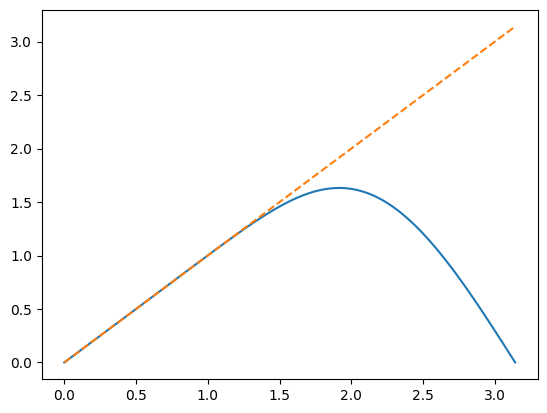

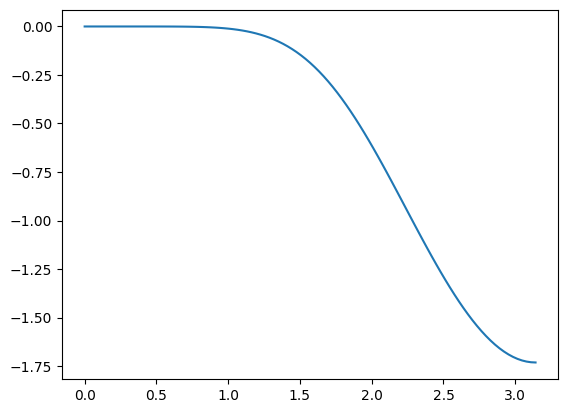

In [1]:
import sys
print(sys.executable)
print(sys.path)
print(sys.executable)
import DNDSR
print(DNDSR.__dict__)
from DNDSR import DNDS
from test_cfv_dissdisp import WaveTester, default_VRSettings
import numpy as np
import matplotlib.pyplot as plt

vrSettings = default_VRSettings()

# vrSettings["functionalSettings"]["dirWeightScheme"] = "Factorial"
# vrSettings["functionalSettings"]["scaleMultiplier"] = 0.5

mpi = DNDS.MPIInfo()
mpi.setWorld()
tester = WaveTester(mpi, vrSettings)
print(tester.test_one_wave(np.pi * 0.1, 0.0))
kxs = np.linspace(0, 1, 101) * np.pi
kappaNum = np.zeros_like(kxs, dtype=np.complex128)
for ikx, kx in enumerate(kxs):
    kappaNum[ikx] = 1j * tester.test_one_wave(kx, np.pi * 0.0, tol=1e-15)

plt.figure(0)
plt.plot(kxs, np.real(kappaNum))
plt.plot(kxs, kxs, ls="--")
plt.show()

plt.figure(1)
plt.plot(kxs, np.imag(kappaNum))
plt.show()

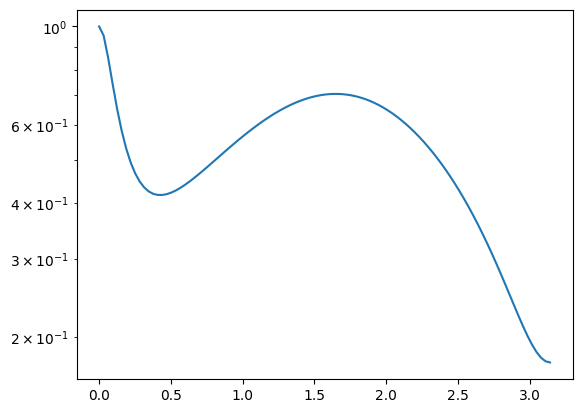

In [11]:
kxs = np.linspace(0, 1, 101) * np.pi
conv_rate = np.zeros_like(kxs, dtype=np.complex128)
for ikx, kx in enumerate(kxs):
    conv_rate[ikx] = tester.test_conv_rate(
        10, kx, np.pi * 0.0, singlegrid_niter=1, multigrid_niters=(0, 0)
    )


plt.figure(0)
plt.plot(kxs, np.abs(conv_rate))
ax = plt.gca()
ax.set_yscale("log")
plt.show()